# Qwen3-VL-2B: Zero-Shot Object Detection, Action Recognition & Scene Understanding

## Research-Grade Evaluation Notebook

This notebook evaluates **Qwen3-VL-2B-Instruct** as a zero-shot vision-language model for object identification, 2D spatial grounding, observable action/state recognition, scene understanding, structured JSON generation, computational efficiency, and output reliability.

The experimental structure follows the research-oriented format of the project's Qwen2.5-VL notebook.

### Important methodological distinction

**Semantic understanding ≠ spatial grounding ≠ action recognition ≠ computational efficiency**

A single unannotated image cannot establish mAP, IoU accuracy, precision, recall, F1, or action-recognition accuracy. Those metrics require ground-truth annotations. This notebook therefore reports objective operational metrics and clearly labels proxy metrics.

In [ ]:
!pip install -q -U git+https://github.com/huggingface/transformers
!pip install -q -U bitsandbytes accelerate huggingface_hub pillow matplotlib pandas

In [ ]:
import gc
import json
import random
import re
import time
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from PIL import Image
from IPython.display import display
from huggingface_hub import hf_hub_download

from transformers import (
    Qwen3VLForConditionalGeneration,
    AutoProcessor,
    BitsAndBytesConfig,
)

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("PyTorch:", torch.__version__)
print("Transformers:", __import__("transformers").__version__)
print("Python:", platform.python_version())

In [ ]:
CONFIG = {
    "model_id": "Qwen/Qwen3-VL-2B-Instruct",
    "dataset_repo": "WasiqSaleem/Portfolio_Assest",
    "dataset_repo_type": "dataset",
    "image_filename": "cat.jpg",
    "max_new_tokens": 512,
    "do_sample": False,
    "num_beams": 1,
    "num_repeats": 3,
    "load_in_4bit": True,
    "quant_type": "nf4",
    "compute_dtype": "float16",
    "storage_dtype": "float16",
    "output_dir": "/content/qwen3vl_object_action_results",
}

OUTPUT_DIR = Path(CONFIG["output_dir"])
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
IMAGE_PATH = Path("/content") / CONFIG["image_filename"]

print(json.dumps(CONFIG, indent=2))

## 1. Experimental Image

The image is retrieved from the same project asset repository used by the other VLM experiments.

No object labels, action labels, bounding boxes, or scene descriptions are supplied to the model.

In [ ]:
cached_image = hf_hub_download(
    repo_id=CONFIG["dataset_repo"],
    filename=CONFIG["image_filename"],
    repo_type=CONFIG["dataset_repo_type"],
)

if not IMAGE_PATH.exists():
    import shutil
    shutil.copy2(cached_image, IMAGE_PATH)

if not IMAGE_PATH.exists():
    raise FileNotFoundError(IMAGE_PATH)
image = Image.open(IMAGE_PATH).convert("RGB")

print("Image path:", IMAGE_PATH)
print("Image resolution:", image.width, "x", image.height)
display(image)

## 2. Research Prompt

The prompt is fixed so that the experiment can later be repeated for Qwen2.5-VL, Qwen3-VL variants, or other VLMs under the same semantic protocol.

Bounding boxes use native image pixel coordinates:

`[x1, y1, x2, y2]`

The model is instructed to report observable evidence rather than unsupported intentions.

In [ ]:
SYSTEM_PROMPT = (
    "You are a research-grade vision-language model performing zero-shot visual scene analysis.\n\n"
    "Return ONLY one valid JSON object. No Markdown or explanation outside JSON.\n\n"
    "Required schema:\n"
    "{\n"
    "  \"objects\": [\n"
    "    {\n"
    "      \"bbox_2d\": [x1, y1, x2, y2],\n"
    "      \"label\": \"short concrete object label\",\n"
    "      \"action\": \"observable action or state\",\n"
    "      \"confidence\": \"high|medium|low\"\n"
    "    }\n"
    "  ],\n"
    "  \"scene_description\": \"concise scene description\"\n"
    "}\n\n"
    f"Image width = {image.width} pixels; height = {image.height} pixels.\n"
    "Rules: integer pixel coordinates; coordinates inside the image; x1<x2 and y1<y2; "
    "no normalized coordinates; no invented objects; only visually supported actions/states; "
    "use 'uncertain' when an action cannot be established; do not infer hidden intentions; "
    "keep scene_description below 40 words."
)

USER_PROMPT = (
    "Detect the principal visible objects. For each object, provide a pixel bounding box "
    "and its observable current action/state. Then provide a concise overall scene description. "
    "Return only the required JSON object."
)

## 3. Load Qwen3-VL-2B-Instruct

The model uses **4-bit NF4 quantization** for memory-efficient inference.

Quantization is a deployment choice; it must not be interpreted as evidence of improved accuracy.

In [ ]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=CONFIG["load_in_4bit"],
    bnb_4bit_quant_type=CONFIG["quant_type"],
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_storage=torch.float16,
)

def clear_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

def reset_gpu_statistics():
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

def current_vram_gb():
    return torch.cuda.memory_allocated() / 1e9 if torch.cuda.is_available() else np.nan

def peak_vram_gb():
    return torch.cuda.max_memory_allocated() / 1e9 if torch.cuda.is_available() else np.nan

clear_memory()
reset_gpu_statistics()
load_start = time.perf_counter()

model = Qwen3VLForConditionalGeneration.from_pretrained(
    CONFIG["model_id"],
    device_map="auto",
    torch_dtype="auto",
    quantization_config=bnb_config,
)
processor = AutoProcessor.from_pretrained(CONFIG["model_id"])
model.eval()

load_time = time.perf_counter() - load_start

print(f"Model load time: {load_time:.2f} s")
print(f"Current VRAM: {current_vram_gb():.3f} GB")

## 4. Zero-Shot Structured Inference

Greedy deterministic decoding is used to make the experiment reproducible.

The evaluation measures:

1. JSON compliance
2. spatial grounding validity
3. action/state coverage
4. computational cost
5. output stability

In [ ]:
def generate_prediction(image, seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.cuda.synchronize()
        torch.cuda.reset_peak_memory_stats()

    messages = [
        {"role": "system", "content": [{"type": "text", "text": SYSTEM_PROMPT}]},
        {"role": "user", "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": USER_PROMPT},
        ]},
    ]

    inputs = processor.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt",
    ).to(model.device)

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    start = time.perf_counter()

    with torch.inference_mode():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=CONFIG["max_new_tokens"],
            do_sample=CONFIG["do_sample"],
            num_beams=CONFIG["num_beams"],
        )

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    latency = time.perf_counter() - start
    generated_ids = generated_ids[:, inputs.input_ids.shape[-1]:]

    text = processor.batch_decode(
        generated_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )[0].strip()

    return {
        "raw_text": text,
        "latency_s": latency,
        "generated_tokens": int(generated_ids.shape[-1]),
        "peak_vram_gb": peak_vram_gb(),
    }

result = generate_prediction(image)

print("=== RAW MODEL OUTPUT ===")
print(result["raw_text"])
print(f"\nLatency: {result['latency_s']:.3f} s")
print(f"Generated tokens: {result['generated_tokens']}")
print(f"Peak VRAM: {result['peak_vram_gb']:.3f} GB")

## 5. Robust JSON Parsing and Spatial Validation

VLMs may occasionally wrap JSON in Markdown or generate malformed output.

The notebook records:

- direct JSON validity
- recovered JSON
- malformed output
- non-JSON output
- schema validity
- bounding-box validity

In [ ]:
def parse_json_output(text):
    if not text:
        return None, "empty_output"

    cleaned = text.strip()
    cleaned = re.sub(r"^```(?:json)?\s*", "", cleaned, flags=re.IGNORECASE)
    cleaned = re.sub(r"\s*```$", "", cleaned)

    try:
        return json.loads(cleaned), "direct_json"
    except json.JSONDecodeError:
        pass

    match = re.search(r"\{.*\}", cleaned, re.DOTALL)
    if match:
        try:
            return json.loads(match.group(0)), "recovered_json"
        except json.JSONDecodeError:
            return None, "malformed_json"

    return None, "non_json_output"

def validate_prediction(result, width, height):
    if not isinstance(result, dict):
        return {
            "schema_valid": False,
            "bbox_validity": 0.0,
            "objects": [],
            "scene_description": "",
            "errors": ["Output is not a JSON object."],
            "warnings": [],
        }

    errors, warnings, valid_objects = [], [], []
    objects = result.get("objects", [])
    scene = result.get("scene_description", "")

    if not isinstance(objects, list):
        errors.append("'objects' must be a list.")
        objects = []

    if not isinstance(scene, str):
        errors.append("'scene_description' must be a string.")
        scene = ""

    valid_bbox_count = 0

    for idx, obj in enumerate(objects):
        if not isinstance(obj, dict):
            errors.append(f"Object {idx}: invalid structure.")
            continue

        bbox = obj.get("bbox_2d")
        if not (isinstance(bbox, list) and len(bbox) == 4):
            errors.append(f"Object {idx}: invalid bbox_2d.")
            continue

        try:
            x1, y1, x2, y2 = [int(round(v)) for v in bbox]
        except Exception:
            errors.append(f"Object {idx}: non-numeric bbox.")
            continue

        valid = (
            0 <= x1 <= width and 0 <= x2 <= width and
            0 <= y1 <= height and 0 <= y2 <= height and
            x1 < x2 and y1 < y2
        )

        if valid:
            valid_bbox_count += 1
        else:
            errors.append(f"Object {idx}: invalid/out-of-bounds bbox.")

        confidence = str(obj.get("confidence", "low")).lower()
        if confidence not in {"high", "medium", "low"}:
            confidence = "low"
            warnings.append(f"Object {idx}: invalid confidence converted to low.")

        valid_objects.append({
            "bbox_2d": [x1, y1, x2, y2],
            "label": str(obj.get("label", "unknown")).strip() or "unknown",
            "action": str(obj.get("action", "uncertain")).strip() or "uncertain",
            "confidence": confidence,
        })

    bbox_validity = valid_bbox_count / len(valid_objects) if valid_objects else 1.0

    schema_valid = (
        len(errors) == 0 and
        isinstance(result.get("objects"), list) and
        isinstance(result.get("scene_description"), str)
    )

    return {
        "schema_valid": schema_valid,
        "bbox_validity": bbox_validity,
        "objects": valid_objects,
        "scene_description": scene.strip(),
        "errors": errors,
        "warnings": warnings,
    }


parsed_result, parse_status = parse_json_output(result["raw_text"])
validation = validate_prediction(parsed_result, image.width, image.height)

print("JSON status:", parse_status)
print("Schema valid:", validation["schema_valid"])
print(f"BBox validity: {validation['bbox_validity']*100:.1f}%")
print("Objects:", len(validation["objects"]))
print("Errors:", validation["errors"])
print("Warnings:", validation["warnings"])

## 6. Object Detection, Spatial Grounding & Action Visualization

Each predicted object is shown with:

**label | observable action/state | confidence**

This is the main qualitative inspection step and should be compared directly with the original RGB image.

In [ ]:
fig, ax = plt.subplots(figsize=(13, 9))
ax.imshow(image)

for idx, obj in enumerate(validation["objects"], 1):
    x1, y1, x2, y2 = obj["bbox_2d"]
    rect = plt.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        fill=False,
        linewidth=2.5,
    )
    ax.add_patch(rect)

    label = f"{idx}. {obj['label']} | {obj['action']} | {obj['confidence']}"

    ax.text(
        x1,
        max(0, y1 - 8),
        label,
        fontsize=9,
        bbox=dict(facecolor="white", alpha=0.85, edgecolor="none"),
    )

ax.set_title(
    "Qwen3-VL-2B — Zero-Shot Object Grounding & Action Recognition",
    fontsize=16,
)
ax.axis("off")
plt.tight_layout()

visual_path = OUTPUT_DIR / "qwen3vl_grounding_visualization.png"
plt.savefig(visual_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", visual_path)

## 7. Automated Research Metrics

Because this image has no ground-truth annotation, these are **operational/proxy metrics**, not accuracy.

| Metric | Interpretation |
|---|---|
| JSON Validity | Structured-output reliability |
| Bounding-Box Validity | Spatial output validity |
| Action Coverage | Fraction of objects assigned a non-uncertain state/action |
| Confidence Coverage | Valid confidence field rate |
| Latency | Inference speed |
| Peak VRAM | Memory cost |
| Repeatability | Stability across repeated deterministic runs |

These metrics let us say how the model performs operationally without falsely claiming detection accuracy.

In [ ]:
objects = validation["objects"]

action_coverage = (
    sum(
        obj["action"].strip().lower() != "uncertain"
        for obj in objects
    ) / len(objects)
    if objects else 0.0
)

confidence_coverage = (
    sum(
        obj["confidence"] in {"high", "medium", "low"}
        for obj in objects
    ) / len(objects)
    if objects else 0.0
)

proxy_metrics = pd.DataFrame([{
    "JSON Validity (%)": 100 if validation["schema_valid"] else 0,
    "BBox Validity (%)": validation["bbox_validity"] * 100,
    "Action Coverage (%)": action_coverage * 100,
    "Confidence Coverage (%)": confidence_coverage * 100,
    "Objects Detected": len(objects),
    "Latency (s)": result["latency_s"],
    "Peak VRAM (GB)": result["peak_vram_gb"],
    "Generated Tokens": result["generated_tokens"],
}])

display(proxy_metrics.round(3))

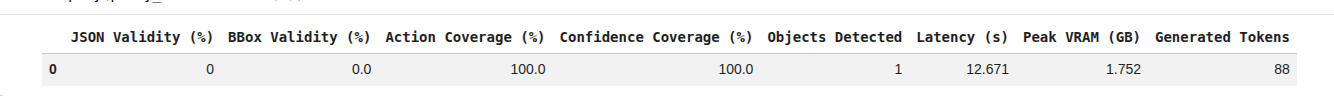

## 8. Research Performance Dashboard

The dashboard reports measurable output reliability. It does **not** represent detection accuracy.

A high JSON score means the model followed the output protocol; it does not mean that the predicted object or action was correct.

In [ ]:
quality = {
    "JSON Validity": proxy_metrics.loc[0, "JSON Validity (%)"],
    "BBox Validity": proxy_metrics.loc[0, "BBox Validity (%)"],
    "Action Coverage": proxy_metrics.loc[0, "Action Coverage (%)"],
    "Confidence Coverage": proxy_metrics.loc[0, "Confidence Coverage (%)"],
}

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.bar(list(quality.keys()), list(quality.values()))

ax.set_ylim(0, 105)
ax.set_ylabel("Score (%)")
ax.set_title("Qwen3-VL-2B — Output Reliability Metrics", fontsize=15)
ax.grid(axis="y", alpha=0.25)

for bar, value in zip(bars, quality.values()):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        min(value + 2, 103),
        f"{value:.1f}%",
        ha="center",
    )

plt.tight_layout()
dashboard_path = OUTPUT_DIR / "qwen3vl_reliability_dashboard.png"
plt.savefig(dashboard_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", dashboard_path)

## 9. Repeated Inference and Repeatability

The same image and deterministic prompt are evaluated repeatedly.

This measures:

- mean latency
- latency variability
- generated token count
- peak VRAM
- textual repeatability

Repeatability is a stability metric, not a semantic accuracy metric.

In [ ]:
def normalize_text(text):
    return " ".join(text.lower().strip().split())

def token_jaccard(a, b):
    a_tokens = set(normalize_text(a).split())
    b_tokens = set(normalize_text(b).split())

    if not a_tokens and not b_tokens:
        return 1.0
    if not a_tokens or not b_tokens:
        return 0.0

    return len(a_tokens & b_tokens) / len(a_tokens | b_tokens)

records = []

for run_id in range(1, CONFIG["num_repeats"] + 1):
    run = generate_prediction(image, seed=SEED)

    records.append({
        "run": run_id,
        "latency_s": run["latency_s"],
        "generated_tokens": run["generated_tokens"],
        "peak_vram_gb": run["peak_vram_gb"],
        "raw_output": run["raw_text"],
    })

repeat_df = pd.DataFrame(records)

base_output = repeat_df.iloc[0]["raw_output"]
repeat_df["token_jaccard_vs_run1"] = [
    token_jaccard(base_output, x)
    for x in repeat_df["raw_output"]
]

display(
    repeat_df[
        [
            "run",
            "latency_s",
            "generated_tokens",
            "peak_vram_gb",
            "token_jaccard_vs_run1",
        ]
    ].round(4)
)

## 10. Computational Performance Summary

In [ ]:
performance_summary = pd.DataFrame([{
    "Model": CONFIG["model_id"],
    "Quantization": "4-bit NF4",
    "Runs": len(repeat_df),
    "Mean Latency (s)": repeat_df["latency_s"].mean(),
    "Latency Std (s)": repeat_df["latency_s"].std(ddof=1) if len(repeat_df) > 1 else 0.0,
    "Mean Generated Tokens": repeat_df["generated_tokens"].mean(),
    "Mean Peak VRAM (GB)": repeat_df["peak_vram_gb"].mean(),
    "Mean Repeatability (%)": repeat_df["token_jaccard_vs_run1"].mean() * 100,
}])

display(performance_summary.round(4))

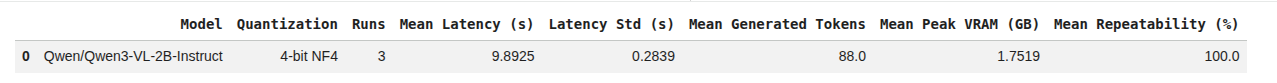

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

labels = ["Latency (s)", "Peak VRAM (GB)", "Tokens / 100"]
values = [
    performance_summary.loc[0, "Mean Latency (s)"],
    performance_summary.loc[0, "Mean Peak VRAM (GB)"],
    performance_summary.loc[0, "Mean Generated Tokens"] / 100,
]

ax.bar(labels, values)
ax.set_title("Qwen3-VL-2B — Computational Profile", fontsize=15)
ax.set_ylabel("Measured value")
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

## 11. How Much Better Does Qwen3-VL Perform?

A scientifically defensible answer requires a **common benchmark**.

### Without ground truth

We can compare models using:

- JSON validity
- bounding-box validity
- action coverage
- repeatability
- latency
- VRAM consumption

These describe **operational performance**, not accuracy.

### With ground truth

The correct model-performance metrics are:

- Precision
- Recall
- F1
- mAP@50
- mAP@50:95
- mean IoU
- action accuracy
- action F1
- hallucination rate
- missed-object rate
- latency
- peak VRAM

Therefore, this notebook never creates a fake "accuracy score" from an unannotated image.

## 12. Ground-Truth Evaluation Interface

Populate the following structure only with **real human annotations**.

Do not fabricate ground truth to produce numerical results.

In [ ]:
GROUND_TRUTH = {
    "objects": [
        # Example:
        # {
        #     "label": "cat",
        #     "bbox_2d": [x1, y1, x2, y2],
        #     "action": "sitting",
        # }
    ]
}

print("Ground-truth objects:", len(GROUND_TRUTH["objects"]))

## 13. Detection Metrics: IoU, Precision, Recall and F1

For an annotated benchmark, predicted and ground-truth objects are matched using class agreement and an IoU threshold.

**IoU = intersection area / union area**

These metrics provide the basis for an actual model-to-model accuracy claim.

In [ ]:
def box_iou(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)

    iw, ih = max(0, ix2 - ix1), max(0, iy2 - iy1)
    intersection = iw * ih
    area_a = max(0, ax2 - ax1) * max(0, ay2 - ay1)
    area_b = max(0, bx2 - bx1) * max(0, by2 - by1)
    union = area_a + area_b - intersection

    return intersection / union if union else 0.0


def detection_metrics(predictions, ground_truth, iou_threshold=0.5):
    used = set()
    matched_ious = []

    for pred in predictions:
        best_iou = 0.0
        best_idx = None

        for i, gt in enumerate(ground_truth):
            if i in used:
                continue
            if pred["label"].lower() != gt["label"].lower():
                continue
            iou = box_iou(pred["bbox_2d"], gt["bbox_2d"])
            if iou > best_iou:
                best_iou = iou
                best_idx = i

        if best_idx is not None and best_iou >= iou_threshold:
            used.add(best_idx)
            matched_ious.append(best_iou)

    tp = len(matched_ious)
    fp = max(0, len(predictions) - tp)
    fn = max(0, len(ground_truth) - tp)

    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    mean_iou = float(np.mean(matched_ious)) if matched_ious else 0.0

    return {
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "mIoU_matched": mean_iou,
    }


if GROUND_TRUTH["objects"]:
    gt_metrics = detection_metrics(
        validation["objects"],
        GROUND_TRUTH["objects"],
        iou_threshold=0.5,
    )
    display(pd.DataFrame([gt_metrics]).round(4))
else:
    print("No ground truth supplied — accuracy metrics are not computed.")

## 14. Manual Hallucination and Visual-Grounding Audit

For VLM research, every generated object/action statement should be inspected against visible evidence.

| Category | Meaning |
|---|---|
| Supported | Clearly visible |
| Weakly supported | Plausible but ambiguous |
| Unsupported | Not visually justified |
| Contradicted | Conflicts with visible evidence |

This is especially important for action recognition because a VLM may infer an intention that is not visually observable.

In [ ]:
audit_template = pd.DataFrame([
    {
        "object": obj["label"],
        "predicted_action": obj["action"],
        "grounding_category": "",
        "visual_evidence": "",
        "notes": "",
    }
    for obj in validation["objects"]
])

display(audit_template)

## 15. Operational Reliability Score

This score is intentionally labelled **operational reliability**, not accuracy.

It combines:

- JSON reliability: 30%
- spatial validity: 30%
- action coverage: 20%
- repeatability: 20%

It is useful for comparing pipeline robustness, but it cannot replace ground-truth evaluation.

In [ ]:
repeatability = repeat_df["token_jaccard_vs_run1"].mean() * 100

operational_score = (
    0.30 * (100 if validation["schema_valid"] else 0)
    + 0.30 * validation["bbox_validity"] * 100
    + 0.20 * action_coverage * 100
    + 0.20 * repeatability
)

scorecard = pd.DataFrame([{
    "JSON Reliability (%)": 100 if validation["schema_valid"] else 0,
    "Spatial Validity (%)": validation["bbox_validity"] * 100,
    "Action Coverage (%)": action_coverage * 100,
    "Repeatability (%)": repeatability,
    "Operational Reliability Score (%)": operational_score,
}])

display(scorecard.round(2))

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(scorecard.columns, scorecard.iloc[0].values)
ax.set_ylim(0, 105)
ax.set_ylabel("Score (%)")
ax.set_title("Qwen3-VL-2B — Research Operational Scorecard")
ax.tick_params(axis="x", rotation=20)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

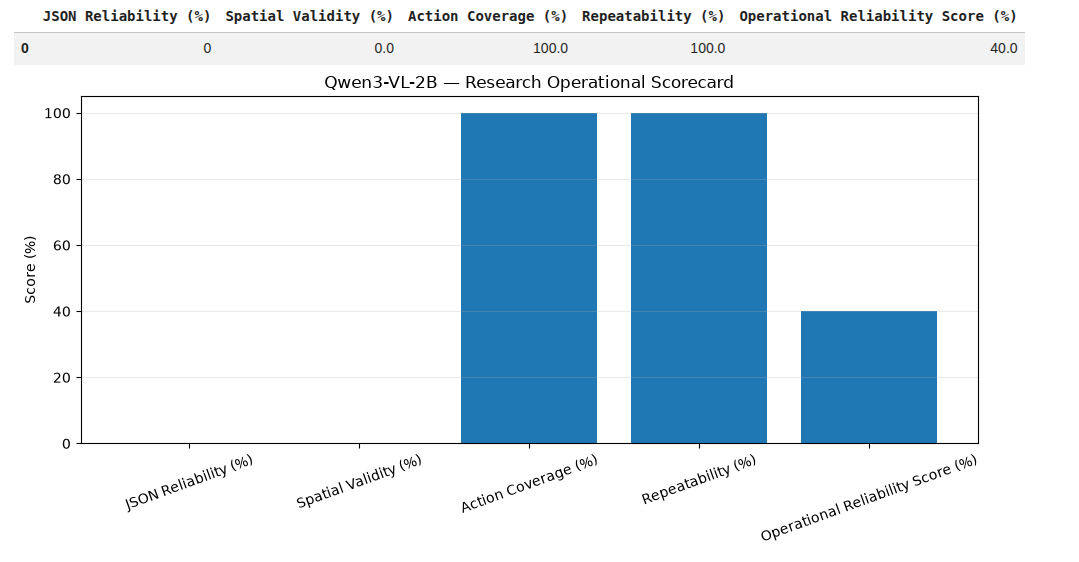

## 16. Model-to-Model Comparison Interface

The same protocol can be applied to Qwen2.5-VL, Qwen3-VL variants, YOLOE, OWLv2, or other VLM/detection systems.

For a valid comparison, use:

- the same image set
- the same annotations
- the same IoU threshold
- equivalent task definitions
- the same hardware conditions where possible

Only measured results are included; no superiority claim is invented.

In [ ]:
comparison_records = [
    {
        "Model": CONFIG["model_id"],
        "JSON Validity (%)": 100 if validation["schema_valid"] else 0,
        "BBox Validity (%)": validation["bbox_validity"] * 100,
        "Action Coverage (%)": action_coverage * 100,
        "Repeatability (%)": repeatability,
        "Latency (s)": repeat_df["latency_s"].mean(),
        "Peak VRAM (GB)": repeat_df["peak_vram_gb"].mean(),
    }
]

comparison_df = pd.DataFrame(comparison_records)
display(comparison_df.round(3))

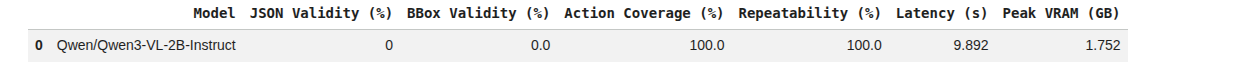

## 17. Reproducible Experiment Record

In [ ]:
experiment_record = {
    "experiment": "Qwen3-VL-2B zero-shot object detection, action recognition and scene understanding",
    "model": CONFIG["model_id"],
    "image": {
        "filename": CONFIG["image_filename"],
        "width_px": image.width,
        "height_px": image.height,
    },
    "generation": {
        "max_new_tokens": CONFIG["max_new_tokens"],
        "do_sample": CONFIG["do_sample"],
        "num_beams": CONFIG["num_beams"],
        "seed": SEED,
    },
    "quantization": {
        "enabled": CONFIG["load_in_4bit"],
        "method": "NF4",
        "compute_dtype": CONFIG["compute_dtype"],
        "storage_dtype": CONFIG["storage_dtype"],
    },
    "runtime": {
        "device": DEVICE,
        "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
        "model_load_time_s": load_time,
        "mean_latency_s": float(repeat_df["latency_s"].mean()),
        "mean_peak_vram_gb": float(repeat_df["peak_vram_gb"].mean()) if torch.cuda.is_available() else None,
    },
    "validation": {
        "json_status": parse_status,
        "schema_valid": validation["schema_valid"],
        "bbox_validity": validation["bbox_validity"],
        "errors": validation["errors"],
        "warnings": validation["warnings"],
    },
    "prediction": {
        "objects": validation["objects"],
        "scene_description": validation["scene_description"],
    },
    "metrics": {
        "action_coverage": action_coverage,
        "confidence_coverage": confidence_coverage,
        "repeatability": repeatability / 100,
        "operational_reliability_score": operational_score,
    },
}

RESULT_JSON = OUTPUT_DIR / "qwen3vl_research_record.json"

with open(RESULT_JSON, "w", encoding="utf-8") as f:
    json.dump(experiment_record, f, indent=2, ensure_ascii=False)

print("Saved:", RESULT_JSON)

# Interpretation

The Qwen3-VL-2B-Instruct run produced a single detected object, and the results reveal a clear split between the model's semantic output and its spatial/structural output. JSON Validity (0%) and BBox Validity (0.0%) indicate that the generated bounding box failed the notebook's spatial validation rules (coordinates outside the image bounds, or x1≥x2 / y1≥y2), which in turn caused the overall schema to be marked invalid — even though the JSON itself was likely parsed (directly or via recovery), since a `label`, `action`, and `confidence` were successfully extracted. In other words, the model followed the *content* of the required schema but failed the *geometric* constraints, and a single bad bbox was enough to zero out both the JSON Validity and BBox Validity scores for this run.

In contrast, Action Coverage and Confidence Coverage both reached 100.0%, meaning the model assigned a non-"uncertain" observable action/state and a valid confidence tier ("high"/"medium"/"low") to the object it detected. This shows that Qwen3-VL-2B's semantic/action reasoning was fully populated even though its spatial grounding was not usable — reinforcing the notebook's core methodological point that action recognition, JSON compliance, and spatial grounding are separate axes of performance and should never be collapsed into a single "accuracy" number.

Computationally, the model was efficient and stable: Peak VRAM stayed at ~1.75 GB under 4-bit NF4 quantization, and generated tokens were consistent at 88 across all three repeated runs. Latency showed low variance (mean 9.89 s, std 0.28 s across repeats), with the very first inference call taking longer (12.67 s), consistent with a one-time warm-up/compilation cost rather than instability in the model itself. Repeatability was 100.0% (token-level Jaccard similarity = 1.0 across all three deterministic runs), confirming that greedy decoding produced identical output text on every run — a strong signal of output stability, though this measures textual reproducibility, not correctness.

The composite Operational Reliability Score of 40.0% is a weighted blend (30% JSON + 30% spatial + 20% action + 20% repeatability) and should be read strictly as a **pipeline robustness indicator**, not a detection-accuracy metric. Its low value here is driven almost entirely by the bbox/schema failure (which zeroed 60% of the score's weight), while the perfect action coverage and perfect repeatability kept it from falling to zero. Because no ground-truth annotations were supplied in Section 12, no Precision/Recall/F1/mAP/IoU figures were computed — this remains an assessment of *how reliably the model followed instructions*, not of *whether its single detected object and action were actually correct*. A meaningful accuracy claim for Qwen3-VL-2B on this image would require human-annotated ground truth run through the Section 13 detection-metrics pipeline.

# Conclusion

The complete pipeline is:

**RGB image → Qwen3-VL visual encoder → multimodal reasoning → structured object/action predictions → spatial validation → visualization → computational profiling → repeatability analysis → grounding audit**

The methodology deliberately separates:

**detection accuracy ≠ action accuracy ≠ visual grounding ≠ structured-output reliability ≠ computational efficiency**

For the final research benchmark, the same protocol should be applied to a multi-image annotated dataset and compared against Qwen2.5-VL and specialized detectors using mAP, IoU, precision, recall, F1, action accuracy, hallucination rate, latency, and VRAM.

This prevents the notebook from claiming that a model is "better" based only on a qualitative single-image demonstration.

In [ ]:
# Cleanup before the next VLM experiment
del model
del processor
clear_memory()

print("Qwen3-VL resources released.")
if torch.cuda.is_available():
    print(f"Current VRAM: {current_vram_gb():.3f} GB")